<a href="https://colab.research.google.com/github/MuhammadRizkyPramadhanaLubis2/UTS-AI/blob/main/animal_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: mrizkyplubis
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/animal-faces


100%|██████████| 696M/696M [00:07<00:00, 96.2MB/s]


In [2]:
import torch
from torch import nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device Available: ", device)

Device Available:  cuda


In [3]:
image_path = []
labels = []

for i in os.listdir("/content/animal-faces/afhq"):
  for label in os.listdir(f"/content/animal-faces/afhq/{i}"):
    for image in os.listdir(f"/content/animal-faces/afhq/{i}/{label}"):
      image_path.append(f"/content/animal-faces/afhq/{i}/{label}/{image}")
      labels.append(label)

data_df = pd.DataFrame(zip(image_path, labels), columns = ["image_path", "labels"])
print(data_df["labels"].unique())
data_df.head()

['cat' 'dog' 'wild']


,image_path,labels
0,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat
1,/content/animal-faces/afhq/val/cat/flickr_cat_...,cat
2,/content/animal-faces/afhq/val/cat/flickr_cat_...,cat
3,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat
4,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat


In [4]:
train = data_df.sample(frac = 0.7)
test = data_df.drop(train.index)

val = test.sample(frac = 0.5)
test = test.drop(val.index)

print(train.shape, test.shape, val.shape)

(11291, 2) (2419, 2) (2420, 2)


In [5]:
label_encoder = LabelEncoder()
label_encoder.fit(data_df["labels"])

transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])

In [6]:
class CustomImageDataset(Dataset):
  def __init__(self, dataframe, transform = None):
    self.dataframe = dataframe
    self.transform = transform
    self.labels = torch.tensor(label_encoder.transform(dataframe['labels'])).to(device)

  def __len__(self):
    return self.dataframe.shape[0]

  def __getitem__(self, idx):
    img_path = self.dataframe.iloc[idx, 0]
    label = self.labels[idx]

    image = Image.open(img_path).convert('RGB')

    if self.transform:
      image = self.transform(image).to(device)

    return image, label

In [7]:
train_dataset = CustomImageDataset(dataframe = train, transform = transform)
test_dataset = CustomImageDataset(dataframe = test, transform = transform)
val_dataset = CustomImageDataset(dataframe = val, transform = transform)

In [8]:
print(train.iloc[2, 0])

/content/animal-faces/afhq/train/cat/pixabay_cat_001532.jpg


In [9]:
train_dataset.__getitem__(2)

(tensor([[[0.6549, 0.6549, 0.6588,  ..., 0.6510, 0.6235, 0.5922],
          [0.5843, 0.6000, 0.6275,  ..., 0.6392, 0.5843, 0.5882],
          [0.6863, 0.7059, 0.7176,  ..., 0.6196, 0.5725, 0.5804],
          ...,
          [0.7804, 0.7765, 0.8000,  ..., 0.3333, 0.3333, 0.3176],
          [0.7725, 0.7725, 0.7961,  ..., 0.3569, 0.3294, 0.3333],
          [0.7765, 0.7843, 0.8118,  ..., 0.3843, 0.3725, 0.3451]],
 
         [[0.5647, 0.5569, 0.5569,  ..., 0.5569, 0.5451, 0.5020],
          [0.4706, 0.4863, 0.5137,  ..., 0.5490, 0.5098, 0.4941],
          [0.5725, 0.6000, 0.6196,  ..., 0.5451, 0.5020, 0.4824],
          ...,
          [0.6784, 0.6471, 0.6588,  ..., 0.2745, 0.2745, 0.2549],
          [0.6627, 0.6431, 0.6588,  ..., 0.2980, 0.2706, 0.2745],
          [0.6667, 0.6549, 0.6745,  ..., 0.3216, 0.3137, 0.2863]],
 
         [[0.3843, 0.3608, 0.3294,  ..., 0.3490, 0.3529, 0.3137],
          [0.2902, 0.2902, 0.2941,  ..., 0.3765, 0.3216, 0.3059],
          [0.3804, 0.3961, 0.4000,  ...,

In [10]:
label_encoder.inverse_transform([0])

array(['cat'], dtype=object)

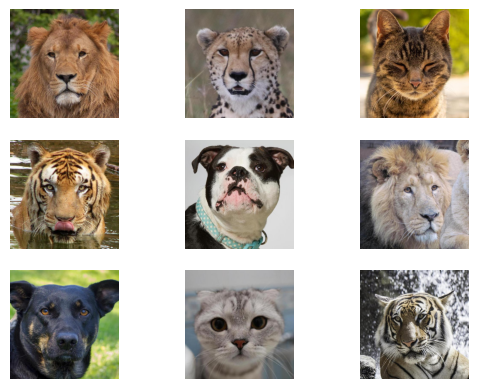

In [11]:
n_rows = 3
n_cols = 3

f, axarr = plt.subplots(n_rows, n_cols)

for row in range(n_rows):
  for col in range(n_cols):
    image = Image.open(data_df.sample(n=1)["image_path"].iloc[0]).convert("RGB")
    axarr[row, col].imshow(image)
    axarr[row, col].axis('off')

In [12]:
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 10

In [13]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [14]:
class Net(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding= 1)
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding= 1)
    self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding= 1)

    self.pooling = nn.MaxPool2d(2, 2)

    self.relu = nn.ReLU()

    self.flatten = nn.Flatten()
    self.linear = nn.Linear((128*16*16), 128)

    self.output = nn.Linear(128, len(data_df['labels'].unique()))

  def forward(self, x):
    x = self.conv1(x)
    x = self.pooling(x)
    x = self.relu(x)

    x = self.conv2(x)
    x = self.pooling(x)
    x = self.relu(x)

    x = self.conv3(x)
    x = self.pooling(x)
    x = self.relu(x)

    x = self.flatten(x)
    x = self.linear(x)
    x = self.output(x)

    return x

In [15]:
model = Net().to(device)

In [16]:
from torchsummary import summary
summary(model, input_size = (3,128,128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
           Linear-12                    [-1, 3]             387
Total params: 4,288,067
Trainable params: 4,288,067
Non-trainable params: 0
---------------------------

In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr = LR)

In [18]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

for epoch in range(EPOCHS):
  total_acc_train = 0
  total_loss_train = 0
  total_loss_val = 0
  total_acc_val = 0

  for inputs, labels in train_loader:
    optimizer.zero_grad()
    outputs = model(inputs)
    train_loss = criterion(outputs, labels)
    total_loss_train += train_loss.item()

    train_loss.backward()

    train_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()

    total_acc_train += train_acc
    optimizer.step()

  with torch.no_grad():
    for inputs, labels in val_loader:
      outputs = model(inputs)
      val_loss = criterion(outputs, labels)
      total_loss_val += val_loss.item()

      val_acc = (torch.argmax(outputs, axis= 1) == labels).sum().item()
      total_acc_val += val_acc

  total_loss_train_plot.append(round(total_loss_train/1000, 4))
  total_loss_validation_plot.append(round(total_loss_val/1000, 4))

  total_acc_train_plot.append(round((total_acc_train/train_dataset.__len__()) * 100, 4))
  total_acc_validation_plot.append(round((total_acc_val/val_dataset.__len__()) * 100, 4))

  print(f'''Epoch {epoch +1}/{EPOCHS},
            Train Loss: {round(total_loss_train/1000, 4)} Train Accuracy {round((total_acc_train/train_dataset.__len__()) * 100, 4)}
            Validation Loss {round(total_loss_val/1000, 4)} Validation Accuracy {round((total_acc_val/val_dataset.__len__()) * 100, 4)}
        ''')

Epoch 1/10,
            Train Loss: 0.3285 Train Accuracy 81.2151
            Validation Loss 0.0408 Validation Accuracy 89.5868
        
Epoch 2/10,
            Train Loss: 0.1429 Train Accuracy 92.4807
            Validation Loss 0.0243 Validation Accuracy 94.1736
        
Epoch 3/10,
            Train Loss: 0.0883 Train Accuracy 95.3768
            Validation Loss 0.0255 Validation Accuracy 94.1322
        
Epoch 4/10,
            Train Loss: 0.0626 Train Accuracy 96.909
            Validation Loss 0.0199 Validation Accuracy 95.1653
        
Epoch 5/10,
            Train Loss: 0.0455 Train Accuracy 97.6884
            Validation Loss 0.0222 Validation Accuracy 94.3388
        
Epoch 6/10,
            Train Loss: 0.0344 Train Accuracy 98.335
            Validation Loss 0.0201 Validation Accuracy 95.5372
        
Epoch 7/10,
            Train Loss: 0.0252 Train Accuracy 98.7424
            Validation Loss 0.0183 Validation Accuracy 96.281
        
Epoch 8/10,
            Train Loss: 0

In [19]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0
  for inputs, labels in test_loader:
    predictions = model(inputs)

    acc = (torch.argmax(predictions, axis = 1) == labels).sum().item()
    total_acc_test += acc
    test_loss = criterion(predictions, labels)
    total_loss_test += test_loss.item()

print(f"Accuracy Score is: {round((total_acc_test/test_dataset.__len__()) * 100, 4)} and Loss is {round(total_loss_test/1000, 4)}")


Accuracy Score is: 95.9901 and Loss is 0.0206


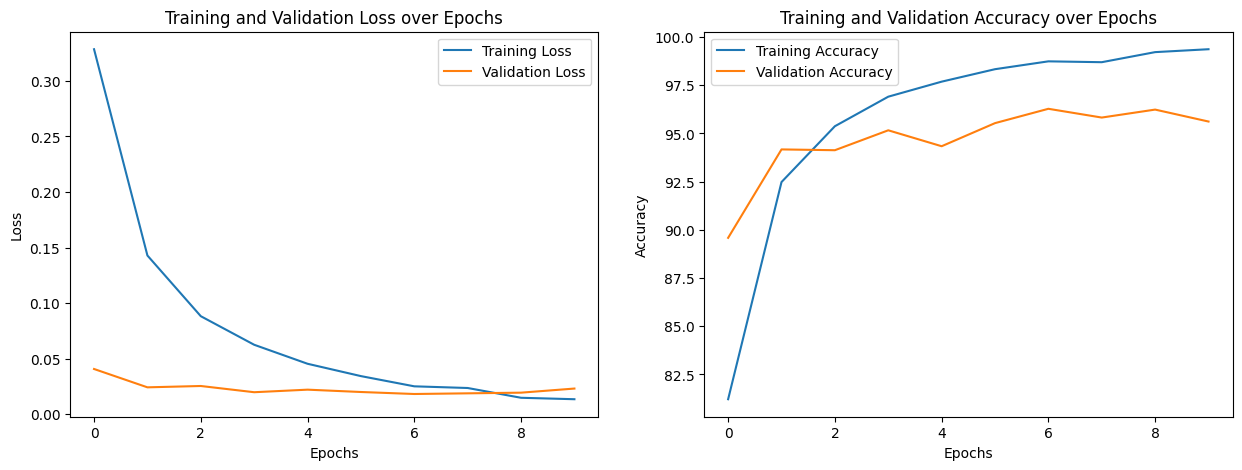

In [20]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 5))

axs[0].plot(total_loss_train_plot, label = 'Training Loss')
axs[0].plot(total_loss_validation_plot, label = 'Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(total_acc_train_plot, label = 'Training Accuracy')
axs[1].plot(total_acc_validation_plot, label = 'Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

plt.show()

In [21]:
def predict_image(image_path):
  image = Image.open("/content/cat.jpg").convert('RGB')
  image = transform(image).to(device)
  output = model(image.unsqueeze(0))

  output = torch.argmax(output, axis= 1).item()
  return label_encoder.inverse_transform([output])

In [22]:
predict_image("/content/cat.jpg")

FileNotFoundError: [Errno 2] No such file or directory: '/content/cat.jpg'